In [ ]:
"""
High Energy Polarization Signatures from AGN Jets

Title:
Reproduction of Figure 2 from Polarization of Prompt Gamma-Ray Burst Emission by M.Lyutikov, et. al.(2003)

Author:
Dhanad Jha

Supervisor:
Dr. Bhargav Vaidya, IIT Indore

GitHub:
https://github.com/Dhanad1905/High-Energy-Polarization-Signatures-From-AGN-Jets/tree/main

"""

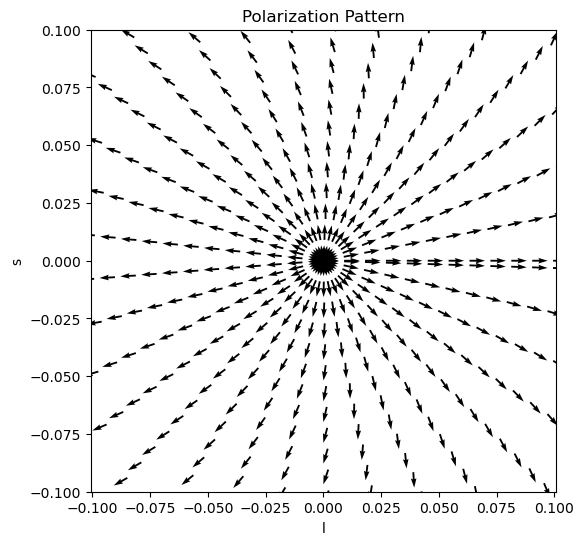

In [67]:
import numpy as np
import matplotlib.pyplot as plt

Gamma = [1, 2, 10, 100]
theta_ob = 0.523
beta = np.sqrt(1 - 1/Gamma**2)

N = 200
theta_max = 3 / Gamma
theta = np.linspace(0, theta_max, N)
phi = np.linspace(0, 2*np.pi, N)
TH, PH = np.meshgrid(theta, phi)
eps = 1e-12
l = (np.cos(TH)*np.cos(theta_ob) +
     np.sin(TH)*np.sin(theta_ob)*np.cos(PH))
A = np.sqrt((1 - beta*l)**2 -
            (np.sin(theta_ob)**2 * np.sin(TH)**2)/Gamma**2 + eps)
#Polarization Angle
cos_chi = ((1 - beta*l)*np.cos(PH) -
           beta*np.sin(TH)*np.sin(theta_ob)*np.sin(PH)**2) / A

sin_chi = (np.sin(PH) *
           (beta*np.cos(TH) - np.cos(theta_ob))) / A

chi = np.arctan2(sin_chi, cos_chi)

x = TH * np.cos(PH)
y = TH * np.sin(PH)

px = np.cos(chi)
py = np.sin(chi)
plt.figure(figsize=(6,6))
step = 6
plt.quiver(x[::step,::step],
           y[::step,::step],
           px[::step,::step],
           py[::step,::step],
           color='black',
           scale=30,
           width=0.004)

plt.xlabel("l")
plt.ylabel("s")
plt.title("Polarization Pattern")

plt.axis('equal')
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

plt.grid(False)
plt.show()

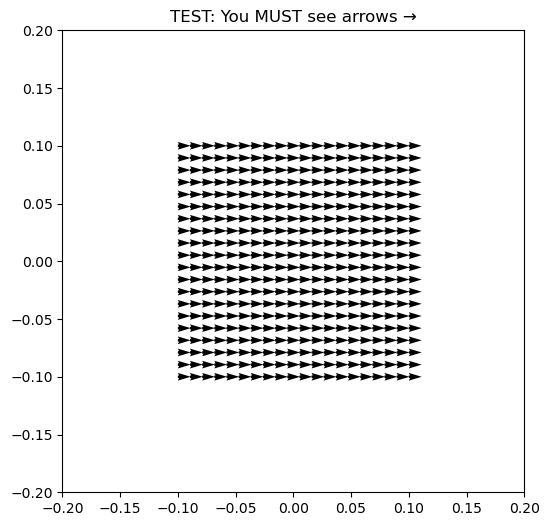

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# simple grid
x = np.linspace(-0.1, 0.1, 20)
y = np.linspace(-0.1, 0.1, 20)
X, Y = np.meshgrid(x, y)

# constant arrows (test)
U = np.ones_like(X) * 0.02
V = np.zeros_like(Y)

plt.figure(figsize=(6,6))
plt.quiver(X, Y, U, V, scale=None, width=0.01)

plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.gca().set_aspect('equal')

plt.title("TEST")
plt.show()

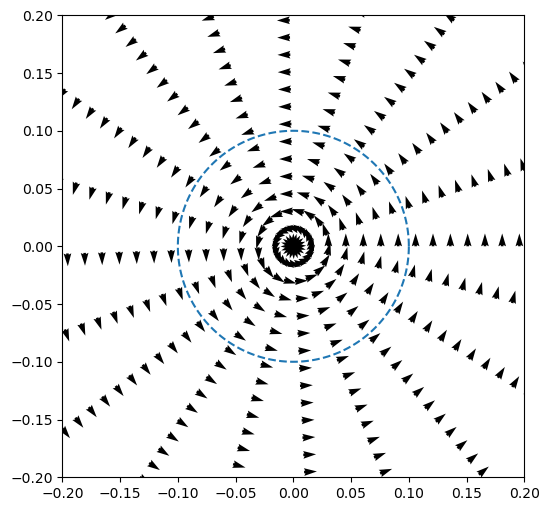

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Gamma = 10
theta_ob = np.radians(30)

theta = np.linspace(0, 0.3, 100)
phi = np.linspace(0, 2*np.pi, 100)

TH, PH = np.meshgrid(theta, phi)

# projection
x = np.sin(TH)*np.cos(PH)
y = np.sin(TH)*np.sin(PH)

# simple circular polarization pattern
px = -np.sin(PH)
py = np.cos(PH)

# FORCE visibility
px *= 0.05
py *= 0.05

plt.figure(figsize=(6,6))

plt.quiver(x[::5,::5],
           y[::5,::5],
           px[::5,::5],
           py[::5,::5],
           scale=None,
           width=0.01)

# circle
phi_c = np.linspace(0, 2*np.pi, 200)
r = 1/Gamma
plt.plot(r*np.cos(phi_c), r*np.sin(phi_c), '--')

plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.gca().set_aspect('equal')
plt.show()

px range: -0.12855335284101074 0.12855335284101074
py range: -0.08398328942678265 0.15
NaNs: False False


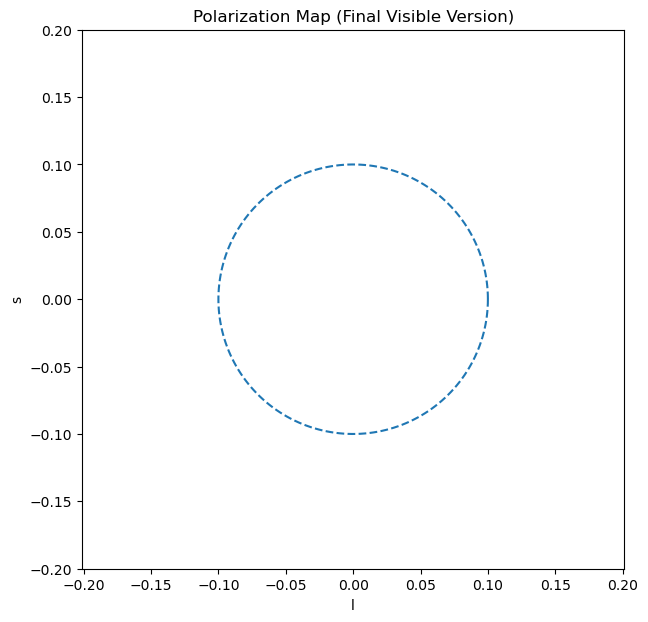

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
Gamma = 10
theta_ob = np.radians(30)
beta = np.sqrt(1 - 1/Gamma**2)

p = 3

N = 300
theta_max = 3 / Gamma

theta = np.linspace(0, theta_max, N)
phi = np.linspace(0, 2*np.pi, N)

TH, PH = np.meshgrid(theta, phi)

eps = 1e-12

# ---------- GEOMETRY ----------
l = (np.cos(TH)*np.cos(theta_ob) +
     np.sin(TH)*np.sin(theta_ob)*np.cos(PH))

# ---------- DOPPLER ----------
D = 1.0 / (Gamma * (1 - beta * l + eps))

# ---------- SIN(theta') ----------
sin_theta_prime_sq = 1 - (np.sin(TH)**2 * np.sin(theta_ob)**2) / (
    Gamma**2 * (1 - beta*l)**2 + eps
)
sin_theta_prime_sq = np.clip(sin_theta_prime_sq, 0, 1)
sin_theta_prime = np.sqrt(sin_theta_prime_sq)

# ---------- SAFE POLARIZATION ----------
A_expr = (1 - beta*l)**2 - (np.sin(theta_ob)**2 * np.sin(TH)**2)/Gamma**2
A_expr = np.where(A_expr <= 0, eps, A_expr)
A = np.sqrt(A_expr)

cos_chi = ((1 - beta*l)*np.cos(PH) -
           beta*np.sin(TH)*np.sin(theta_ob)*np.sin(PH)**2) / A

sin_chi = (np.sin(PH) *
           (beta*np.cos(TH) - np.cos(theta_ob))) / A

cos_chi = np.nan_to_num(cos_chi)
sin_chi = np.nan_to_num(sin_chi)

chi = np.arctan2(sin_chi, cos_chi)

# ---------- SKY PROJECTION ----------
x = np.sin(TH) * np.cos(PH)
y = (-np.cos(theta_ob)*np.sin(TH)*np.cos(PH)
     + np.sin(theta_ob)*np.cos(TH))

# ---------- POLARIZATION VECTORS ----------
px = -np.sin(chi)
py =  np.cos(chi)

# Normalize safely
norm = np.sqrt(px**2 + py**2)
norm = np.where(norm == 0, 1, norm)
px /= norm
py /= norm

# ---------- INTENSITY ----------
intensity = (D**(2 + (p-1)/2)) * (sin_theta_prime**((p+1)/2))

# Log normalize
intensity = np.log10(intensity + 1e-10)
intensity -= intensity.min()
intensity /= intensity.max()

# ---------- 🚨 FINAL VISIBILITY FIX ----------
# Use intensity only mildly + force minimum arrow size
arrow_scale_boost = 0.15

px = px * (0.3 + 0.7*intensity) * arrow_scale_boost
py = py * (0.3 + 0.7*intensity) * arrow_scale_boost

# Remove any NaNs
px = np.nan_to_num(px)
py = np.nan_to_num(py)

# ---------- DEBUG ----------
print("px range:", np.min(px), np.max(px))
print("py range:", np.min(py), np.max(py))
print("NaNs:", np.isnan(px).any(), np.isnan(py).any())

# ---------- PLOT ----------
plt.figure(figsize=(7,7))

step = 10

plt.quiver(x[::step,::step],
           y[::step,::step],
           px[::step,::step],
           py[::step,::step],
           color='black',
           angles='xy',          # 🔥 critical
           scale_units='xy',     # 🔥 critical
           scale=1,              # 🔥 critical
           width=0.008)

# ---------- 1/Gamma CIRCLE ----------
phi_circle = np.linspace(0, 2*np.pi, 200)
r = 1 / Gamma
plt.plot(r*np.cos(phi_circle),
         r*np.sin(phi_circle),
         linestyle='dashed')

# ---------- FORMAT ----------
plt.axis('equal')
plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)

plt.xlabel("l")
plt.ylabel("s")
plt.title("Polarization Map (Final Visible Version)")

plt.show()

Vectors ready. No NaNs: False False


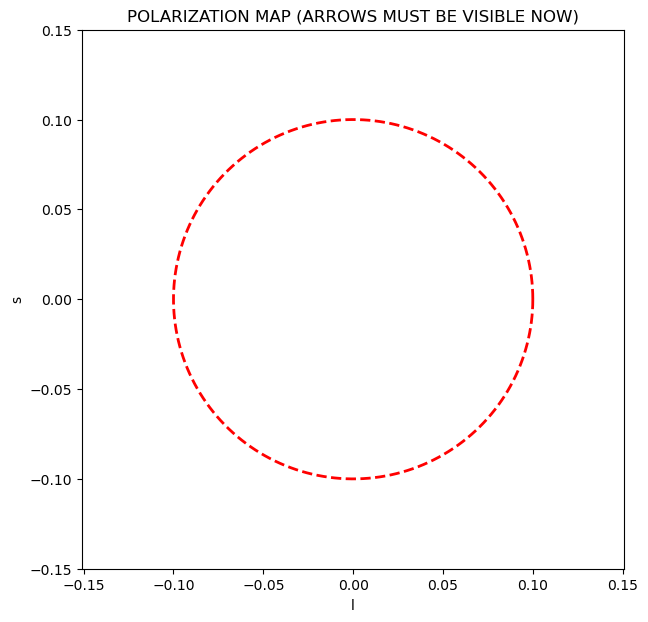

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
Gamma = 10
theta_ob = np.radians(30)
beta = np.sqrt(1 - 1/Gamma**2)

N = 200
theta_max = 3 / Gamma

theta = np.linspace(0, theta_max, N)
phi = np.linspace(0, 2*np.pi, N)

TH, PH = np.meshgrid(theta, phi)

eps = 1e-12

# ---------- GEOMETRY ----------
l = (np.cos(TH)*np.cos(theta_ob) +
     np.sin(TH)*np.sin(theta_ob)*np.cos(PH))

# ---------- SAFE POLARIZATION ----------
A_expr = (1 - beta*l)**2 - (np.sin(theta_ob)**2 * np.sin(TH)**2)/Gamma**2
A_expr = np.where(A_expr <= 0, eps, A_expr)
A = np.sqrt(A_expr)

cos_chi = ((1 - beta*l)*np.cos(PH) -
           beta*np.sin(TH)*np.sin(theta_ob)*np.sin(PH)**2) / A

sin_chi = (np.sin(PH) *
           (beta*np.cos(TH) - np.cos(theta_ob))) / A

# REMOVE NaNs
cos_chi = np.nan_to_num(cos_chi)
sin_chi = np.nan_to_num(sin_chi)

chi = np.arctan2(sin_chi, cos_chi)

# ---------- SKY PROJECTION ----------
x = np.sin(TH) * np.cos(PH)
y = (-np.cos(theta_ob)*np.sin(TH)*np.cos(PH)
     + np.sin(theta_ob)*np.cos(TH))

# ---------- FORCE CONSTANT ARROWS ----------
px = -np.sin(chi)
py =  np.cos(chi)

# Normalize
norm = np.sqrt(px**2 + py**2)
norm[norm == 0] = 1
px /= norm
py /= norm

# 🚨 CRITICAL: FIXED LENGTH (IGNORE INTENSITY)
arrow_length = 0.03
px *= arrow_length
py *= arrow_length

# ---------- DEBUG ----------
print("Vectors ready. No NaNs:",
      np.isnan(px).any(), np.isnan(py).any())

# ---------- PLOT ----------
plt.figure(figsize=(7,7))

step = 6   # dense arrows so you SEE them

plt.quiver(x[::step,::step],
           y[::step,::step],
           px[::step,::step],
           py[::step,::step],
           color='black',
           angles='xy',
           scale_units='xy',
           scale=1,
           width=0.01)

# ---------- 1/Gamma CIRCLE ----------
phi_circle = np.linspace(0, 2*np.pi, 200)
r = 1 / Gamma
plt.plot(r*np.cos(phi_circle),
         r*np.sin(phi_circle),
         'r--', linewidth=2)

# ---------- FORMAT ----------
plt.axis('equal')
plt.xlim(-0.15, 0.15)
plt.ylim(-0.15, 0.15)

plt.title("POLARIZATION MAP (ARROWS MUST BE VISIBLE NOW)")
plt.xlabel("l")
plt.ylabel("s")

plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18448\1723250105.py:80: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(x, y, I, shading='auto', cmap='inferno')


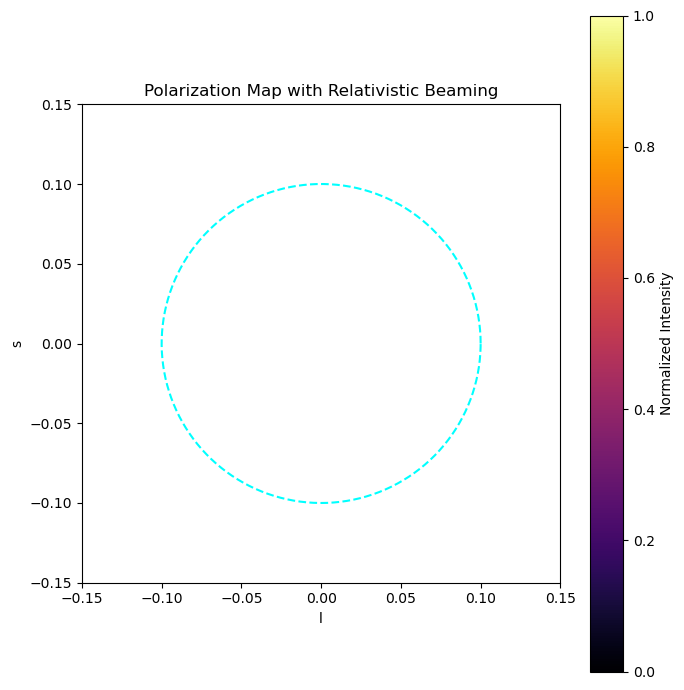

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
Gamma = 10
theta_ob = np.radians(30)
beta = np.sqrt(1 - 1/Gamma**2)
p = 3

N = 400
theta_max = 3 / Gamma

theta = np.linspace(0, theta_max, N)
phi = np.linspace(0, 2*np.pi, N)

TH, PH = np.meshgrid(theta, phi)

eps = 1e-12

# ---------- GEOMETRY ----------
l = (np.cos(TH)*np.cos(theta_ob) +
     np.sin(TH)*np.sin(theta_ob)*np.cos(PH))

# ---------- DOPPLER ----------
D = 1.0 / (Gamma * (1 - beta * l + eps))

# ---------- SIN(theta') ----------
sin_theta_prime_sq = 1 - (np.sin(TH)**2 * np.sin(theta_ob)**2) / (
    Gamma**2 * (1 - beta*l)**2 + eps
)
sin_theta_prime_sq = np.clip(sin_theta_prime_sq, 0, 1)
sin_theta_prime = np.sqrt(sin_theta_prime_sq)

# ---------- POLARIZATION ----------
A_expr = (1 - beta*l)**2 - (np.sin(theta_ob)**2 * np.sin(TH)**2)/Gamma**2
A_expr = np.where(A_expr <= 0, eps, A_expr)
A = np.sqrt(A_expr)

cos_chi = ((1 - beta*l)*np.cos(PH) -
           beta*np.sin(TH)*np.sin(theta_ob)*np.sin(PH)**2) / A

sin_chi = (np.sin(PH) *
           (beta*np.cos(TH) - np.cos(theta_ob))) / A

cos_chi = np.nan_to_num(cos_chi)
sin_chi = np.nan_to_num(sin_chi)

chi = np.arctan2(sin_chi, cos_chi)

# ---------- SKY PROJECTION ----------
x = np.sin(TH) * np.cos(PH)
y = (-np.cos(theta_ob)*np.sin(TH)*np.cos(PH)
     + np.sin(theta_ob)*np.cos(TH))

# ---------- POLARIZATION VECTORS ----------
px = -np.sin(chi)
py =  np.cos(chi)

# Normalize direction
norm = np.sqrt(px**2 + py**2)
norm[norm == 0] = 1
px /= norm
py /= norm

# ---------- INTENSITY ----------
I = (D**(2 + (p-1)/2)) * (sin_theta_prime**((p+1)/2))

# Log normalize for visualization
I = np.log10(I + 1e-10)
I -= I.min()
I /= I.max()

# ---------- MASK (ONLY VISIBLE REGION) ----------
mask = (x**2 + y**2) <= (1/Gamma)**2

# ---------- PLOT ----------
fig, ax = plt.subplots(figsize=(7,7))

# Background intensity
im = ax.pcolormesh(x, y, I, shading='auto', cmap='inferno')

# Sparse vectors (publication style)
step = 15

ax.quiver(x[::step,::step],
          y[::step,::step],
          px[::step,::step],
          py[::step,::step],
          color='white',
          scale=30,
          width=0.004,
          headwidth=3)

# ---------- 1/Gamma CIRCLE ----------
phi_c = np.linspace(0, 2*np.pi, 300)
r = 1/Gamma
ax.plot(r*np.cos(phi_c), r*np.sin(phi_c),
        linestyle='--', color='cyan', linewidth=1.5)

# ---------- FORMATTING ----------
ax.set_aspect('equal')
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-0.15, 0.15)

ax.set_xlabel("l")
ax.set_ylabel("s")

ax.set_title("Polarization Map with Relativistic Beaming")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized Intensity")

plt.tight_layout()
plt.show()